In [2]:
from google.colab import auth
auth.authenticate_user()

project_id = 'churn-propensity-model'

print("Authentication successful")

Authentication successful


# Churn Propensity Model — Exploratory Data Analysis

## Business context
Telco customer churn prediction across 7,043 customers.
Target: predict which customers will churn in the next billing cycle.

## Hypotheses to test
1. Contract type is the strongest structural churn signal
2. Monthly charges direction reverses between new and old customers  
3. Electronic check is a proxy for at-risk customer profile
4. Bundle depth (number of services) reduces churn via switching friction

## Dataset
- 7,043 customers, 21 features
- 26.54% churn rate — healthy imbalance for modelling
- Three tenure segments: day0 (0 months), new (1-12 months), old (12+ months)

In [3]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project=project_id)

df = client.query("""
    SELECT *
    FROM `churn-propensity-model.churn_ds.feature_store`
""").to_dataframe()

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nChurn rate: {df['churn_label'].mean():.2%}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (7043, 23)

Columns: ['customerID', 'churn_label', 'tenure', 'tenure_segment', 'gender_male', 'is_senior', 'has_partner', 'has_dependents', 'contract_type', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'has_phone', 'multiple_lines', 'internet_service', 'has_online_security', 'has_tech_support', 'has_online_backup', 'has_device_protection', 'has_streaming_tv', 'has_streaming_movies', 'event_date']

Churn rate: 26.54%

First 3 rows:


,customerID,churn_label,tenure,tenure_segment,gender_male,is_senior,has_partner,has_dependents,contract_type,paperless_billing,...,has_phone,multiple_lines,internet_service,has_online_security,has_tech_support,has_online_backup,has_device_protection,has_streaming_tv,has_streaming_movies,event_date
0,8464-EETCQ,False,57,old,1,0,0,0,Two year,0,...,1,0,No,-1,-1,-1,-1,-1,-1,2024-01-30
1,2718-YSKCS,False,71,old,1,0,1,1,Two year,1,...,1,0,No,-1,-1,-1,-1,-1,-1,2024-01-30
2,0362-RAOQO,False,40,old,0,0,0,0,Two year,0,...,1,0,No,-1,-1,-1,-1,-1,-1,2024-01-30


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Quick sanity check
print("Libraries loaded")
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Churn rate: {df['churn_label'].mean():.2%}")
print(f"Tenure segments:\n{df['tenure_segment'].value_counts()}")

Libraries loaded
Dataset: 7,043 rows × 23 columns
Churn rate: 26.54%
Tenure segments:
tenure_segment
old     4857
new     2175
day0      11
Name: count, dtype: int64


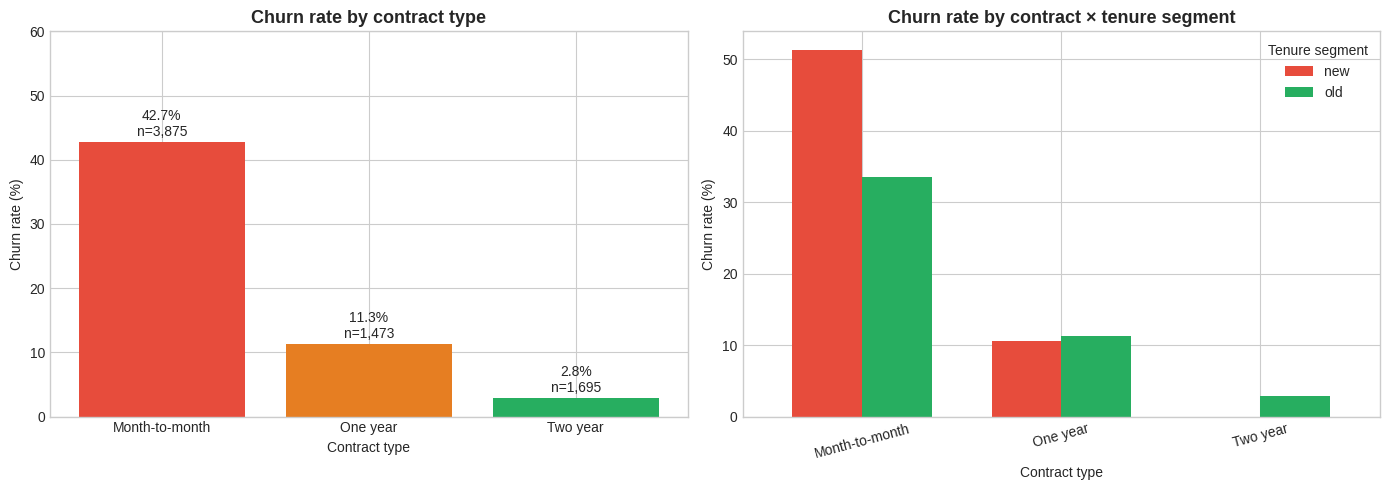


Hypothesis 1 verdict:
Month-to-month churn: 42.7%
Two year churn: 2.8%
Ratio: 15.1x higher churn on month-to-month


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot — churn rate by contract type
contract_churn = df.groupby('contract_type')['churn_label'].agg(['mean', 'count']).reset_index()
contract_churn['churn_rate_pct'] = contract_churn['mean'] * 100
contract_churn = contract_churn.sort_values('churn_rate_pct', ascending=False)

bars = axes[0].bar(
    contract_churn['contract_type'],
    contract_churn['churn_rate_pct'],
    color=['#e74c3c', '#e67e22', '#27ae60']
)
axes[0].set_title('Churn rate by contract type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Contract type')
axes[0].set_ylabel('Churn rate (%)')
axes[0].set_ylim(0, 60)

for bar, (_, row) in zip(bars, contract_churn.iterrows()):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{row['churn_rate_pct']:.1f}%\nn={row['count']:,}",
        ha='center', fontsize=10
    )

# Right plot — churn rate by contract AND tenure segment
pivot = df.groupby(['contract_type', 'tenure_segment'])['churn_label'].mean().unstack() * 100
pivot = pivot.reindex(['Month-to-month', 'One year', 'Two year'])
pivot[['new', 'old']].plot(
    kind='bar',
    ax=axes[1],
    color=['#e74c3c', '#27ae60'],
    width=0.7
)
axes[1].set_title('Churn rate by contract × tenure segment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Contract type')
axes[1].set_ylabel('Churn rate (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
axes[1].legend(title='Tenure segment')

plt.tight_layout()
plt.savefig('contract_churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nHypothesis 1 verdict:")
print(f"Month-to-month churn: {contract_churn[contract_churn['contract_type']=='Month-to-month']['churn_rate_pct'].values[0]:.1f}%")
print(f"Two year churn: {contract_churn[contract_churn['contract_type']=='Two year']['churn_rate_pct'].values[0]:.1f}%")
print(f"Ratio: {contract_churn[contract_churn['contract_type']=='Month-to-month']['churn_rate_pct'].values[0] / contract_churn[contract_churn['contract_type']=='Two year']['churn_rate_pct'].values[0]:.1f}x higher churn on month-to-month")

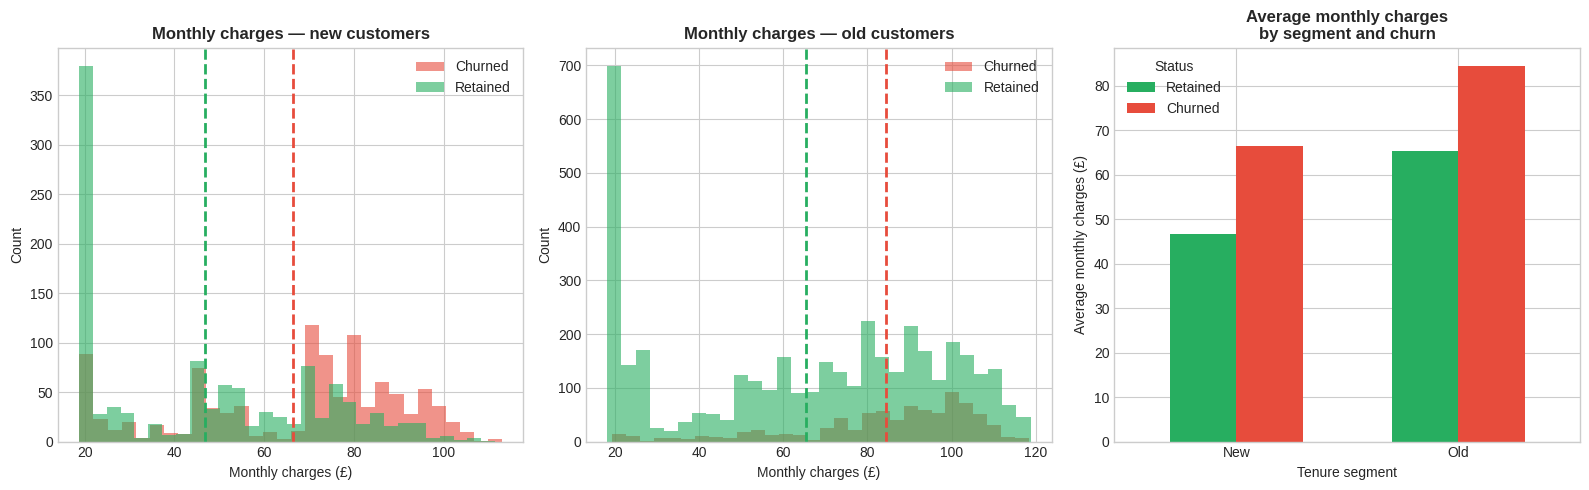


Hypothesis 2 verdict:

NEW customers:
  Churned avg monthly charges:  £66.49
  Retained avg monthly charges: £46.77
  Churners pay HIGHER — difference: £19.73

OLD customers:
  Churned avg monthly charges:  £84.35
  Retained avg monthly charges: £65.42
  Churners pay HIGHER — difference: £18.93


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

segments = ['new', 'old']
colors_churn = {True: '#e74c3c', False: '#27ae60'}
labels = {True: 'Churned', False: 'Retained'}

# Left and middle — distribution of monthly charges by churn within each segment
for idx, segment in enumerate(segments):
    segment_df = df[df['tenure_segment'] == segment]

    for churn_val in [True, False]:
        subset = segment_df[segment_df['churn_label'] == churn_val]['monthly_charges']
        axes[idx].hist(
            subset,
            bins=30,
            alpha=0.6,
            color=colors_churn[churn_val],
            label=labels[churn_val]
        )

    axes[idx].set_title(f'Monthly charges — {segment} customers',
                         fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Monthly charges (£)')
    axes[idx].set_ylabel('Count')
    axes[idx].legend()

    churned_mean = segment_df[segment_df['churn_label']==True]['monthly_charges'].mean()
    retained_mean = segment_df[segment_df['churn_label']==False]['monthly_charges'].mean()
    axes[idx].axvline(churned_mean, color='#e74c3c', linestyle='--', linewidth=2)
    axes[idx].axvline(retained_mean, color='#27ae60', linestyle='--', linewidth=2)

# Right — average monthly charges by churn and segment side by side
summary = df[df['tenure_segment'].isin(['new', 'old'])].groupby(
    ['tenure_segment', 'churn_label']
)['monthly_charges'].mean().unstack()
summary.columns = ['Retained', 'Churned']
summary.plot(kind='bar', ax=axes[2], color=['#27ae60', '#e74c3c'], width=0.6)
axes[2].set_title('Average monthly charges\nby segment and churn',
                   fontsize=12, fontweight='bold')
axes[2].set_xlabel('Tenure segment')
axes[2].set_ylabel('Average monthly charges (£)')
axes[2].set_xticklabels(['New', 'Old'], rotation=0)
axes[2].legend(title='Status')

plt.tight_layout()
plt.savefig('monthly_charges_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the numbers
print("\nHypothesis 2 verdict:")
for segment in ['new', 'old']:
    seg_df = df[df['tenure_segment'] == segment]
    churned = seg_df[seg_df['churn_label']==True]['monthly_charges'].mean()
    retained = seg_df[seg_df['churn_label']==False]['monthly_charges'].mean()
    direction = "HIGHER" if churned > retained else "LOWER"
    print(f"\n{segment.upper()} customers:")
    print(f"  Churned avg monthly charges:  £{churned:.2f}")
    print(f"  Retained avg monthly charges: £{retained:.2f}")
    print(f"  Churners pay {direction} — difference: £{abs(churned-retained):.2f}")

## Hypothesis 2 — Partially confirmed, more nuanced than expected

- Monthly charges positively correlate with churn in BOTH segments
- New churners: £66.49 vs retained £46.77 — sticker shock on new bills
- Old churners: £84.35 vs retained £65.42 — premium customers
  actively shopping for better value
- Same direction, different mechanism — one global model treats
  these identically, missing the business distinction entirely
- Implication: retention strategy should differ by segment
  → New: justify the cost early, show value quickly
  → Old: proactive loyalty pricing before they start comparing

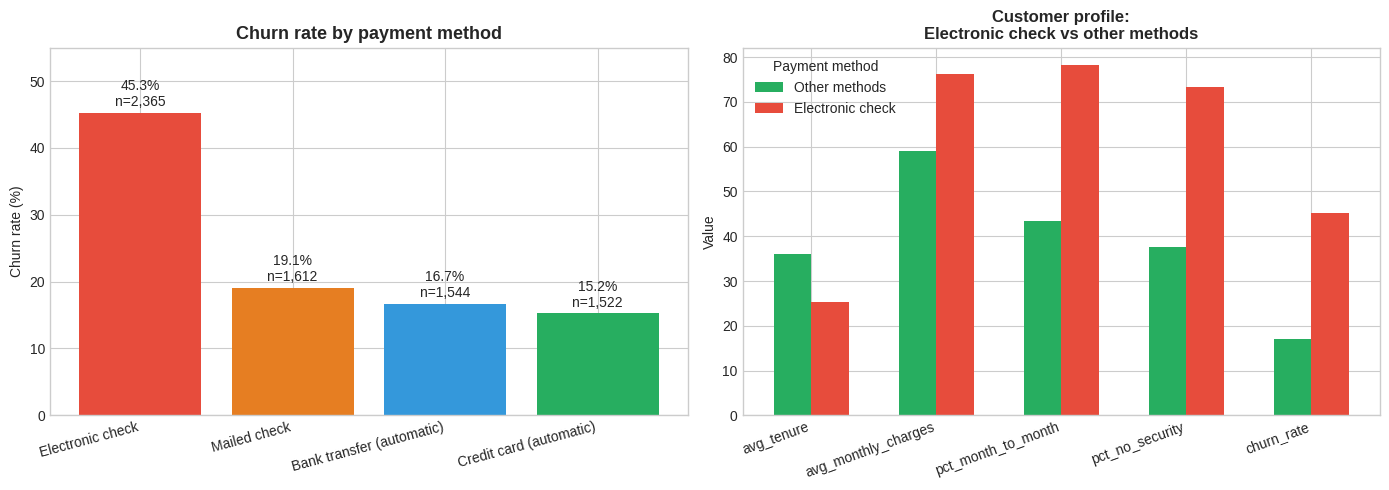


Hypothesis 3 verdict — Electronic check customer profile:
                    Other methods Electronic check
avg_tenure                 36.000           25.200
avg_monthly_charges        59.000           76.300
pct_month_to_month         43.300           78.200
pct_no_security            37.700           73.300
churn_rate                 17.100           45.300


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — churn rate by payment method
payment_churn = df.groupby('payment_method')['churn_label'].agg(
    ['mean', 'count']
).reset_index()
payment_churn['churn_rate_pct'] = payment_churn['mean'] * 100
payment_churn = payment_churn.sort_values('churn_rate_pct', ascending=False)

bars = axes[0].bar(
    range(len(payment_churn)),
    payment_churn['churn_rate_pct'],
    color=['#e74c3c', '#e67e22', '#3498db', '#27ae60']
)
axes[0].set_xticks(range(len(payment_churn)))
axes[0].set_xticklabels(
    payment_churn['payment_method'],
    rotation=15,
    ha='right'
)
axes[0].set_title('Churn rate by payment method', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Churn rate (%)')
axes[0].set_ylim(0, 55)

for bar, (_, row) in zip(bars, payment_churn.iterrows()):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{row['churn_rate_pct']:.1f}%\nn={row['count']:,}",
        ha='center', fontsize=10
    )

# Right — electronic check customer profile vs others
df['is_electronic_check'] = df['payment_method'] == 'Electronic check'

profile_metrics = df.groupby('is_electronic_check').agg(
    avg_tenure=('tenure', 'mean'),
    avg_monthly_charges=('monthly_charges', 'mean'),
    pct_month_to_month=('contract_type', lambda x: (x == 'Month-to-month').mean() * 100),
    pct_no_security=('has_online_security', lambda x: (x == 0).mean() * 100),
    churn_rate=('churn_label', lambda x: x.mean() * 100)
).round(1)

profile_metrics.index = ['Other methods', 'Electronic check']
profile_metrics.T.plot(kind='bar', ax=axes[1], color=['#27ae60', '#e74c3c'], width=0.6)
axes[1].set_title('Customer profile:\nElectronic check vs other methods',
                   fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')
axes[1].legend(title='Payment method')
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.savefig('payment_method_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nHypothesis 3 verdict — Electronic check customer profile:")
print(profile_metrics.T.to_string())

## Hypothesis 3 — Confirmed: electronic check is a profile proxy

Electronic check customers vs all other payment methods:
- 25.2 vs 36 months average tenure — significantly newer
- £76.30 vs £59.00 monthly charges — paying more despite less history
- 78.2% vs 43.3% on month-to-month — almost no contract commitment
- 73.3% vs 37.7% have no security add-on — fewer embedded services
- 45.3% vs 17.1% churn rate — nearly 3x higher churn

Conclusion: electronic check is a proxy for low commitment customers,
not a causal driver of churn. Retention strategy should target the
underlying profile — short tenure, high charges, no contract, no
add-ons — not the payment method itself.

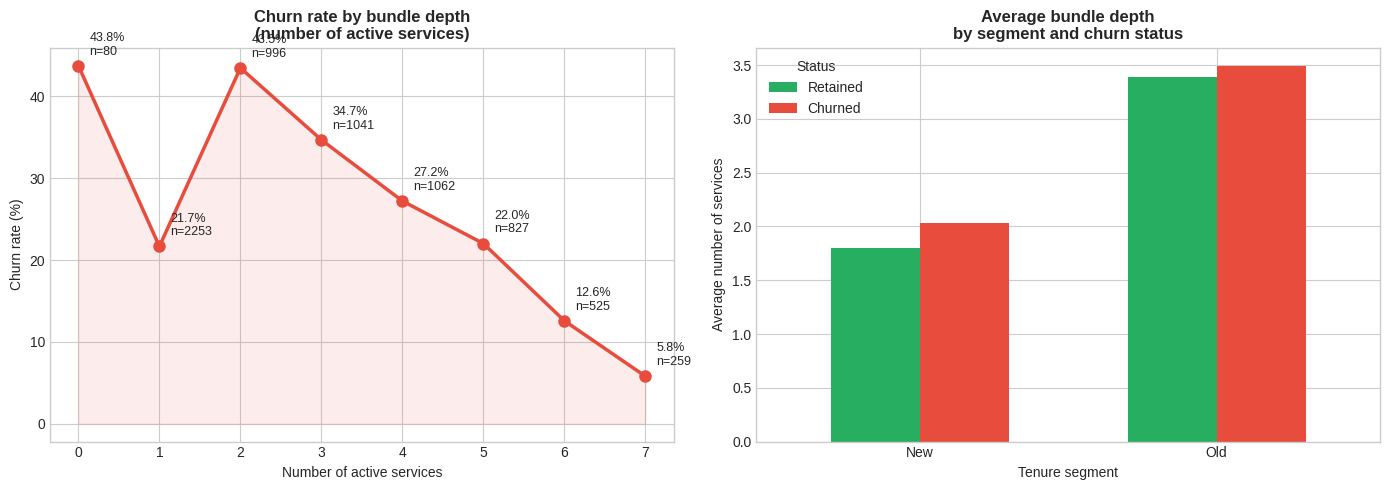


Hypothesis 4 verdict:

NEW customers:
  Retained avg bundle depth: 1.80 services
  Churned avg bundle depth:  2.03 services
  Difference: -0.23 more services for retained customers

OLD customers:
  Retained avg bundle depth: 3.39 services
  Churned avg bundle depth:  3.49 services
  Difference: -0.10 more services for retained customers


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calculate bundle depth — number of active services per customer
service_cols = [
    'has_phone', 'has_online_security', 'has_tech_support',
    'has_online_backup', 'has_device_protection',
    'has_streaming_tv', 'has_streaming_movies'
]

# Count only active services (value = 1, not 0 or -1)
df['bundle_depth'] = df[service_cols].apply(
    lambda row: (row == 1).sum(), axis=1
)

# Left — churn rate by bundle depth
bundle_churn = df.groupby('bundle_depth')['churn_label'].agg(
    ['mean', 'count']
).reset_index()
bundle_churn['churn_rate_pct'] = bundle_churn['mean'] * 100

axes[0].plot(
    bundle_churn['bundle_depth'],
    bundle_churn['churn_rate_pct'],
    marker='o',
    color='#e74c3c',
    linewidth=2.5,
    markersize=8
)
axes[0].fill_between(
    bundle_churn['bundle_depth'],
    bundle_churn['churn_rate_pct'],
    alpha=0.1,
    color='#e74c3c'
)
axes[0].set_title('Churn rate by bundle depth\n(number of active services)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of active services')
axes[0].set_ylabel('Churn rate (%)')
axes[0].set_xticks(bundle_churn['bundle_depth'])

for _, row in bundle_churn.iterrows():
    axes[0].annotate(
        f"{row['churn_rate_pct']:.1f}%\nn={row['count']}",
        xy=(row['bundle_depth'], row['churn_rate_pct']),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=9
    )

# Right — average bundle depth by churn status and tenure segment
bundle_summary = df[df['tenure_segment'].isin(['new', 'old'])].groupby(
    ['tenure_segment', 'churn_label']
)['bundle_depth'].mean().unstack()
bundle_summary.columns = ['Retained', 'Churned']
bundle_summary.plot(
    kind='bar',
    ax=axes[1],
    color=['#27ae60', '#e74c3c'],
    width=0.6
)
axes[1].set_title('Average bundle depth\nby segment and churn status',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tenure segment')
axes[1].set_ylabel('Average number of services')
axes[1].set_xticklabels(['New', 'Old'], rotation=0)
axes[1].legend(title='Status')

plt.tight_layout()
plt.savefig('bundle_depth_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nHypothesis 4 verdict:")
for segment in ['new', 'old']:
    seg = df[df['tenure_segment'] == segment].groupby('churn_label')['bundle_depth'].mean()
    print(f"\n{segment.upper()} customers:")
    print(f"  Retained avg bundle depth: {seg[False]:.2f} services")
    print(f"  Churned avg bundle depth:  {seg[True]:.2f} services")
    print(f"  Difference: {seg[False] - seg[True]:.2f} more services for retained customers")

## Hypothesis 4 — Confirmed with nuance

Bundle depth reduces churn through switching friction, but non-linearly:
- Depth 0: high churn — no services, no reason to stay
- Depth 2: churn spikes — "dipping toe in" segment, not committed
- Depth 3-7: churn drops steadily as switching friction accumulates
- Depth 7: lowest churn — replacing 7 services simultaneously is
  too painful, customers stay even if slightly unhappy

Segment averages are misleading here — the line chart tells the
real story. New customer averages (1.80 vs 2.03) reflect
experimenters who were never going to stay, not bundle depth causing
churn.

Business implication: early upsell to 3+ services is the single
most impactful retention lever for new customers.

In [9]:
print("=" * 55)
print("EDA SUMMARY — KEY FINDINGS FOR MODELLING")
print("=" * 55)

print(f"""
1. CONTRACT TYPE
   Month-to-month churn: {df[df['contract_type']=='Month-to-month']['churn_label'].mean():.1%}
   Two year churn:       {df[df['contract_type']=='Two year']['churn_label'].mean():.1%}
   Ratio: {df[df['contract_type']=='Month-to-month']['churn_label'].mean() / df[df['contract_type']=='Two year']['churn_label'].mean():.1f}x — strongest single feature

2. MONTHLY CHARGES
   New churned:    £{df[(df['tenure_segment']=='new') & (df['churn_label']==True)]['monthly_charges'].mean():.2f}
   New retained:   £{df[(df['tenure_segment']=='new') & (df['churn_label']==False)]['monthly_charges'].mean():.2f}
   Old churned:    £{df[(df['tenure_segment']=='old') & (df['churn_label']==True)]['monthly_charges'].mean():.2f}
   Old retained:   £{df[(df['tenure_segment']=='old') & (df['churn_label']==False)]['monthly_charges'].mean():.2f}

3. ELECTRONIC CHECK
   Churn rate: {df[df['payment_method']=='Electronic check']['churn_label'].mean():.1%} vs
   Others:     {df[df['payment_method']!='Electronic check']['churn_label'].mean():.1%}
   → Proxy for low commitment profile

4. BUNDLE DEPTH
   Depth 0-2: high churn (no switching friction)
   Depth 3+:  churn declines steadily
   Depth 7:   {df[df['bundle_depth']==7]['churn_label'].mean():.1%} churn — lowest
   → Early upsell to 3+ services = best retention lever

MODELLING IMPLICATIONS:
- contract_type will be top feature by importance
- bundle_depth is a strong engineered feature to include
- Separate thresholds needed per tenure_segment
- monthly_charges interacts with tenure_segment
""")

EDA SUMMARY — KEY FINDINGS FOR MODELLING

1. CONTRACT TYPE
   Month-to-month churn: 42.7%
   Two year churn:       2.8%
   Ratio: 15.1x — strongest single feature

2. MONTHLY CHARGES
   New churned:    £66.49
   New retained:   £46.77
   Old churned:    £84.35
   Old retained:   £65.42

3. ELECTRONIC CHECK
   Churn rate: 45.3% vs
   Others:     17.1%
   → Proxy for low commitment profile

4. BUNDLE DEPTH
   Depth 0-2: high churn (no switching friction)
   Depth 3+:  churn declines steadily
   Depth 7:   5.8% churn — lowest
   → Early upsell to 3+ services = best retention lever

MODELLING IMPLICATIONS:
- contract_type will be top feature by importance
- bundle_depth is a strong engineered feature to include
- Separate thresholds needed per tenure_segment
- monthly_charges interacts with tenure_segment



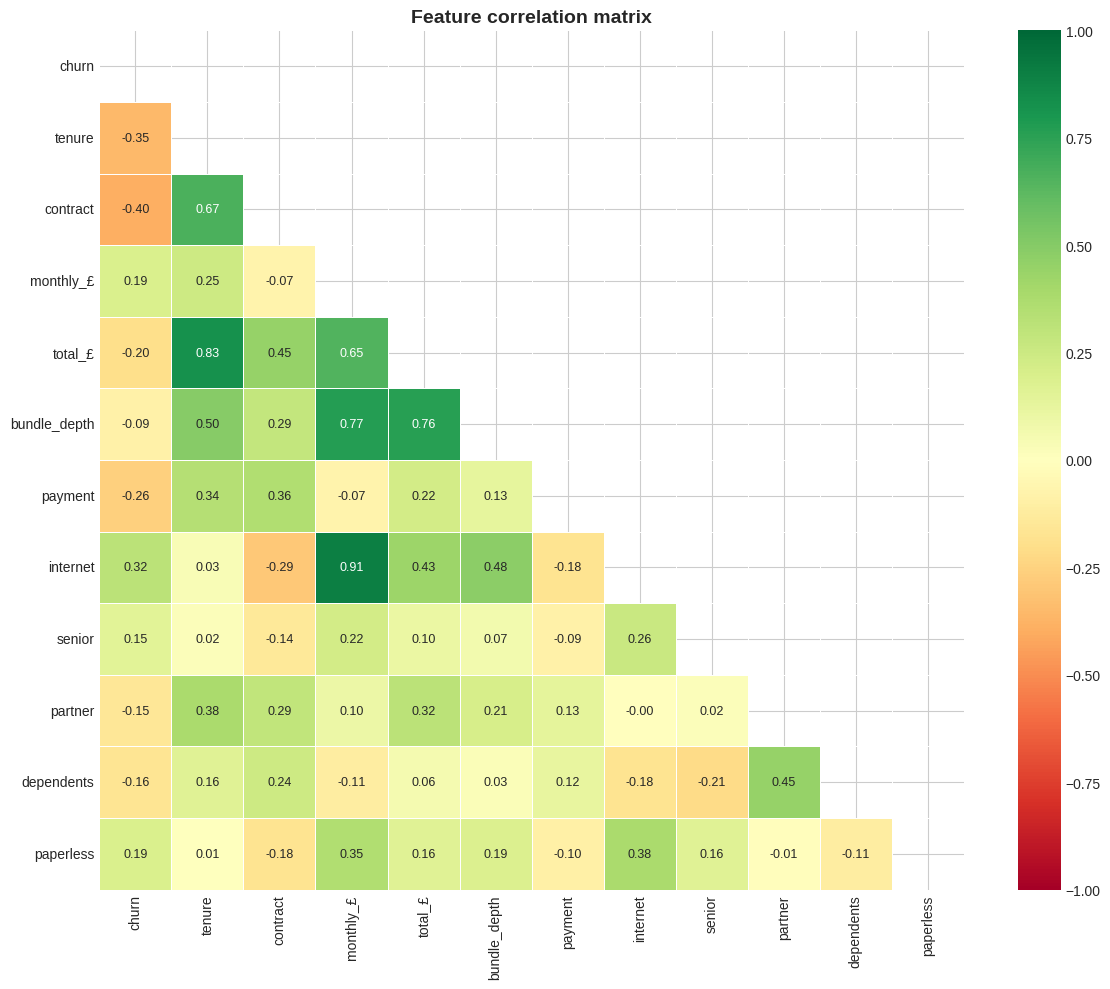


Top correlations with churn (absolute value):
  contract             -0.397
  tenure               -0.352
  internet             +0.317
  payment              -0.263
  total_£              -0.198
  monthly_£            +0.193
  paperless            +0.192
  dependents           -0.164
  senior               +0.151
  partner              -0.150
  bundle_depth         -0.086


In [10]:
# Encode categoricals numerically for correlation
df_corr = df.copy()

df_corr['contract_encoded'] = df_corr['contract_type'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
})

df_corr['payment_encoded'] = df_corr['payment_method'].map({
    'Electronic check': 0,
    'Mailed check': 1,
    'Bank transfer (automatic)': 2,
    'Credit card (automatic)': 3
})

df_corr['internet_encoded'] = df_corr['internet_service'].map({
    'No': 0,
    'DSL': 1,
    'Fiber optic': 2
})

df_corr['churn_int'] = df_corr['churn_label'].astype(int)

corr_cols = [
    'churn_int', 'tenure', 'contract_encoded',
    'monthly_charges', 'total_charges',
    'bundle_depth', 'payment_encoded',
    'internet_encoded', 'is_senior',
    'has_partner', 'has_dependents',
    'paperless_billing'
]

corr_matrix = df_corr[corr_cols].corr()

# Rename for readability
rename_map = {
    'churn_int': 'churn',
    'contract_encoded': 'contract',
    'monthly_charges': 'monthly_£',
    'total_charges': 'total_£',
    'bundle_depth': 'bundle_depth',
    'payment_encoded': 'payment',
    'internet_encoded': 'internet',
    'is_senior': 'senior',
    'has_partner': 'partner',
    'has_dependents': 'dependents',
    'paperless_billing': 'paperless'
}
corr_matrix = corr_matrix.rename(index=rename_map, columns=rename_map)

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 9}
)
ax.set_title('Feature correlation matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with churn
print("\nTop correlations with churn (absolute value):")
churn_corr = corr_matrix['churn'].drop('churn').abs().sort_values(ascending=False)
for feat, val in churn_corr.items():
    direction = "+" if corr_matrix['churn'][feat] > 0 else "-"
    print(f"  {feat:20s} {direction}{val:.3f}")

## EDA conclusions — modelling decisions

### Features to use
- contract_type (strongest signal, 15.1x churn ratio)
- tenure + tenure_segment (strong signal, segment-specific behaviour)
- monthly_charges (strong signal, keep over total_charges)
- bundle_depth (engineered feature, 4.6x churn reduction at depth 7)
- payment_method (proxy for commitment profile)
- internet_service (strong signal despite correlation with monthly_charges)
- has_online_security, has_tech_support (moderate signals)
- has_streaming_tv, has_streaming_movies (moderate signals)
- is_senior, has_partner, has_dependents (weak but kept)
- paperless_billing, gender_male, has_phone (weak, kept for completeness)

### Features dropped
- total_charges — mathematically redundant (tenure × monthly_charges)
  dilutes feature importance without adding new information

### Key modelling implications
- Separate bucket thresholds per tenure_segment (day0/new/old)
- contract_type expected to be top feature by importance
- bundle_depth engineered feature to be included
- XGBoost chosen for non-linear interactions between features
- PR-AUC primary metric (imbalanced classes, 26.54% churn rate)